## Feature Scaling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
X, y = make_classification(
    n_samples=1500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

print(X.shape)
print(y.shape)

(1500, 2)
(1500,)


In [4]:
X[:, 0] = X[:, 0] * 1000

In [5]:
print("Feature 1 range:")
print(X[:, 0].min(), X[:, 0].max())

print("\nFeature 2 range:")
print(X[:, 1].min(), X[:, 1].max())

Feature 1 range:
-1348.1682135619667 4485.408762408342

Feature 2 range:
-4.298646508448391 3.7724433291888437


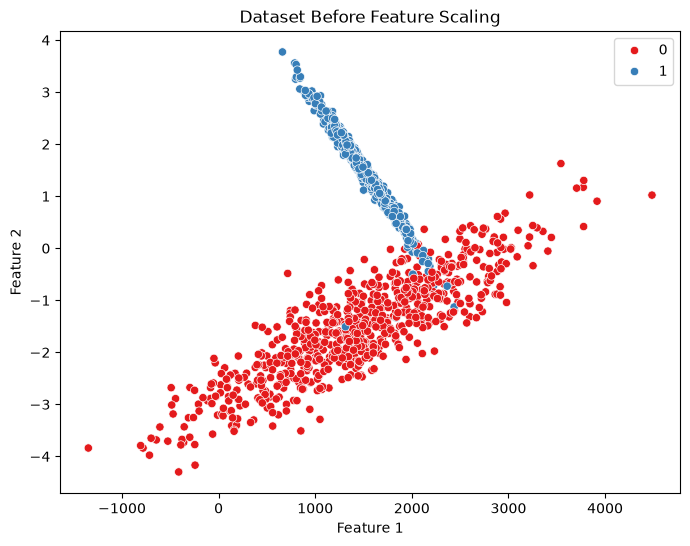

In [6]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y,
    palette="Set1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset Before Feature Scaling")
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1200, 2)
Testing shape: (300, 2)


In [8]:
model_unscaled = Sequential([
    Dense(16, activation="relu", input_shape=(2,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

c:\Users\alili\100_days_Deep_Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model_unscaled.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [10]:
model_unscaled.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_unscaled = model_unscaled.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [12]:
loss_unscaled, accuracy_unscaled = model_unscaled.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Unscaled Test Loss:", loss_unscaled)
print("Unscaled Test Accuracy:", accuracy_unscaled)

Unscaled Test Loss: 0.670444667339325
Unscaled Test Accuracy: 0.550000011920929


In [13]:
y_pred_unscaled = model_unscaled.predict(X_test, verbose=0)

y_pred_unscaled = (y_pred_unscaled > 0.5).astype(int).ravel()

print("Accuracy:",
      accuracy_score(y_test, y_pred_unscaled))

Accuracy: 0.55


### Using Standard Scaler

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
print("Before Scaling")

print("Feature 1 mean:", X_train[:, 0].mean())
print("Feature 1 std :", X_train[:, 0].std())

print("Feature 2 mean:", X_train[:, 1].mean())
print("Feature 2 std :", X_train[:, 1].std())

Before Scaling
Feature 1 mean: 1474.2497583583272
Feature 1 std : 636.1476114391795
Feature 2 mean: -0.03275176190231189
Feature 2 std : 1.7288522627256317


In [16]:
print("\nAfter Scaling")

print("Feature 1 mean:", X_train_scaled[:, 0].mean())
print("Feature 1 std :", X_train_scaled[:, 0].std())

print("Feature 2 mean:", X_train_scaled[:, 1].mean())
print("Feature 2 std :", X_train_scaled[:, 1].std())


After Scaling
Feature 1 mean: 3.282559409475046e-15
Feature 1 std : 1.0000000000000004
Feature 2 mean: -3.404683942183813e-17
Feature 2 std : 1.0000000000000002


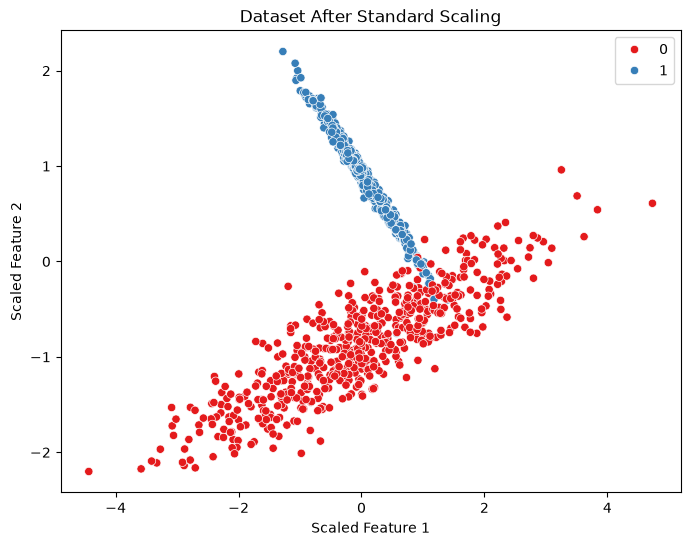

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_train_scaled[:, 0],
    y=X_train_scaled[:, 1],
    hue=y_train,
    palette="Set1"
)

plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.title("Dataset After Standard Scaling")
plt.show()

In [18]:
model_scaled = Sequential([
    Dense(16, activation="relu", input_shape=(2,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

c:\Users\alili\100_days_Deep_Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model_scaled.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history_scaled = model_scaled.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [21]:
loss_scaled, accuracy_scaled = model_scaled.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Scaled Test Loss:", loss_scaled)
print("Scaled Test Accuracy:", accuracy_scaled)

Scaled Test Loss: 0.11577142030000687
Scaled Test Accuracy: 0.9733333587646484


In [22]:
y_pred_scaled = model_scaled.predict(
    X_test_scaled,
    verbose=0
)

y_pred_scaled = (y_pred_scaled > 0.5).astype(int).ravel()

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_scaled)
)

Accuracy: 0.9733333333333334


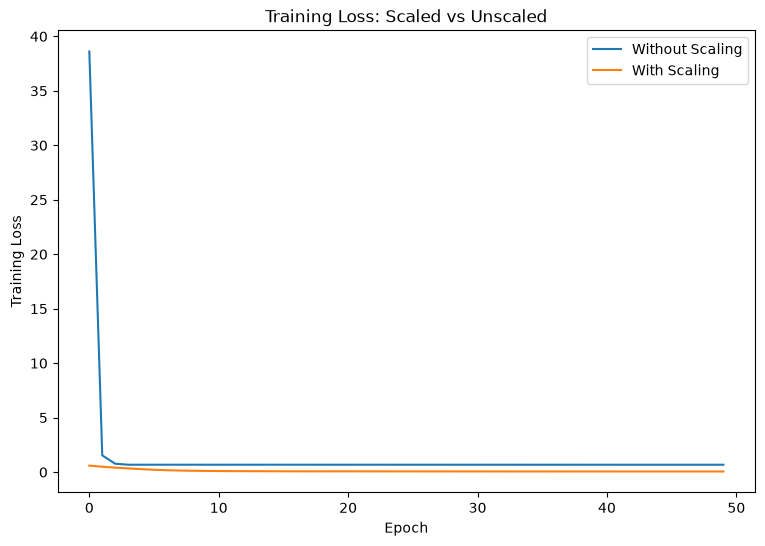

In [23]:
plt.figure(figsize=(9, 6))

plt.plot(
    history_unscaled.history["loss"],
    label="Without Scaling"
)

plt.plot(
    history_scaled.history["loss"],
    label="With Scaling"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Scaled vs Unscaled")
plt.legend()

plt.show()

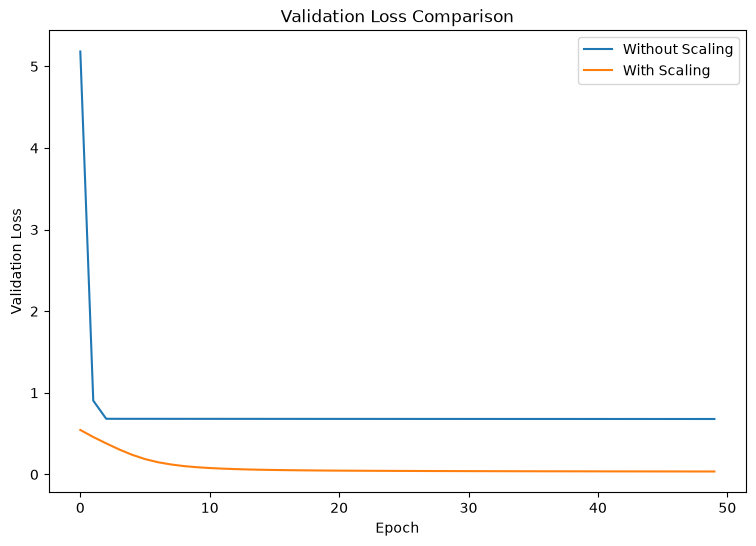

In [24]:
plt.figure(figsize=(9, 6))

plt.plot(
    history_unscaled.history["val_loss"],
    label="Without Scaling"
)

plt.plot(
    history_scaled.history["val_loss"],
    label="With Scaling"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

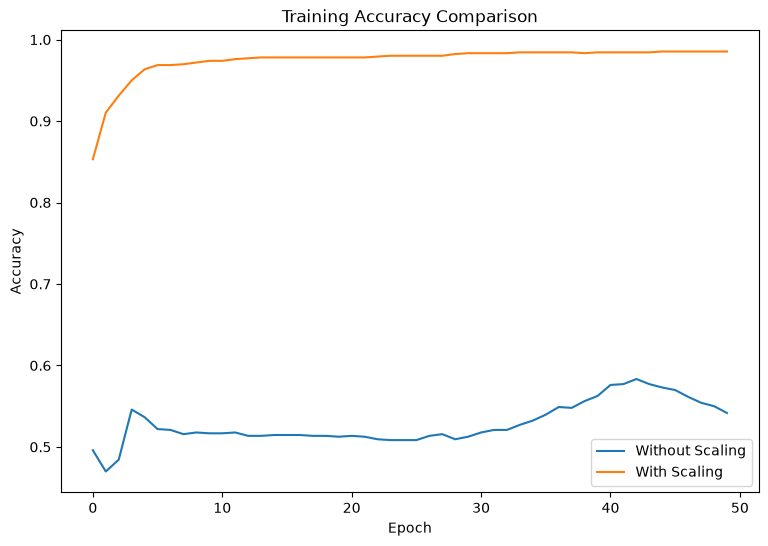

In [25]:
plt.figure(figsize=(9, 6))

plt.plot(
    history_unscaled.history["accuracy"],
    label="Without Scaling"
)

plt.plot(
    history_scaled.history["accuracy"],
    label="With Scaling"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()

plt.show()

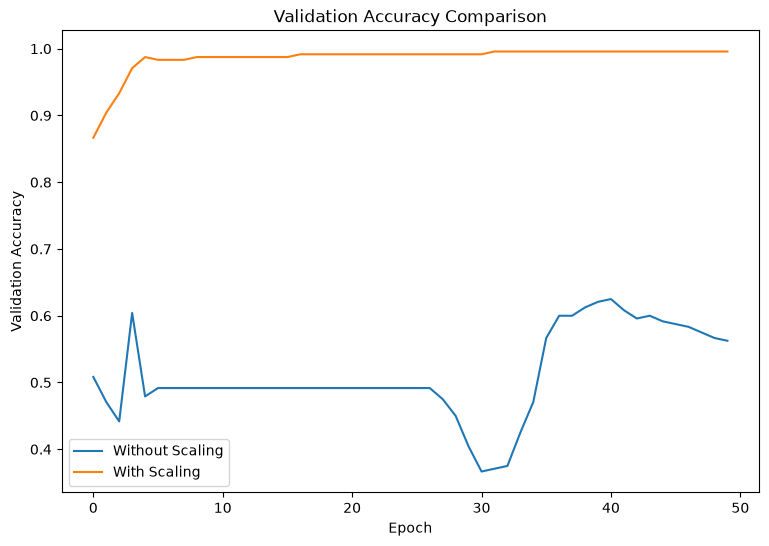

In [26]:
plt.figure(figsize=(9, 6))

plt.plot(
    history_unscaled.history["val_accuracy"],
    label="Without Scaling"
)

plt.plot(
    history_scaled.history["val_accuracy"],
    label="With Scaling"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

In [27]:
results = pd.DataFrame({
    "Model": [
        "Without Scaling",
        "With StandardScaler"
    ],
    
    "Test Loss": [
        loss_unscaled,
        loss_scaled
    ],
    
    "Test Accuracy": [
        accuracy_unscaled,
        accuracy_scaled
    ]
})

results

,Model,Test Loss,Test Accuracy
0,Without Scaling,0.670445,0.550000
1,With StandardScaler,0.115771,0.973333


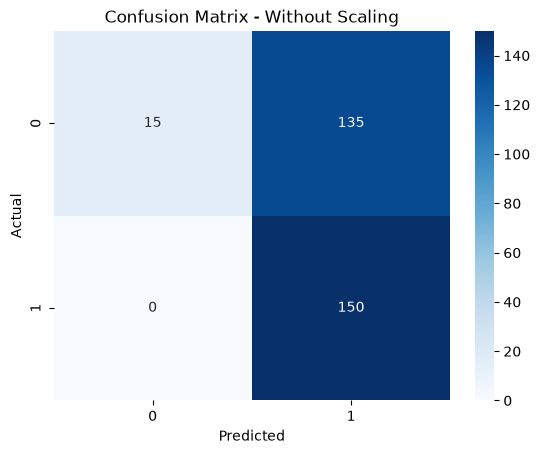

In [28]:
cm_unscaled = confusion_matrix(
    y_test,
    y_pred_unscaled
)

sns.heatmap(
    cm_unscaled,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Without Scaling")
plt.show()

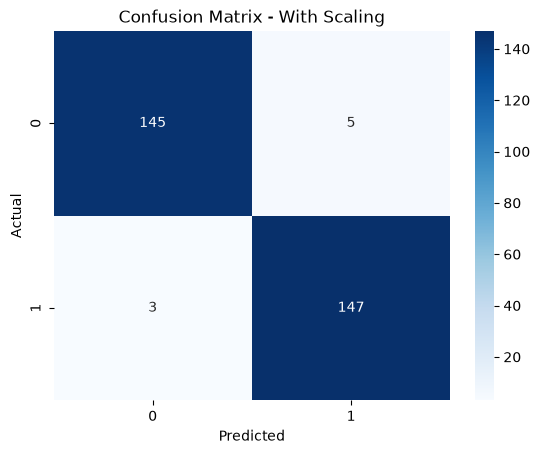

In [29]:
cm_scaled = confusion_matrix(
    y_test,
    y_pred_scaled
)

sns.heatmap(
    cm_scaled,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - With Scaling")
plt.show()

In [30]:
def plot_decision_boundary(model, X, y, title):
    
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    predictions = model.predict(
        grid,
        verbose=0
    )

    predictions = (
        predictions > 0.5
    ).astype(int)

    predictions = predictions.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.3
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="k"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)

    plt.show()

In [31]:
def plot_boundary_unscaled(model, X, y):

    padding_x1 = (X[:, 0].max() - X[:, 0].min()) * 0.1
    padding_x2 = (X[:, 1].max() - X[:, 1].min()) * 0.1

    x1_min = X[:, 0].min() - padding_x1
    x1_max = X[:, 0].max() + padding_x1

    x2_min = X[:, 1].min() - padding_x2
    x2_max = X[:, 1].max() + padding_x2

    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    Z = model.predict(
        grid,
        verbose=0
    )

    Z = (Z > 0.5).astype(int)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="k"
    )

    plt.title(
        "Decision Boundary - Without Feature Scaling"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.show()

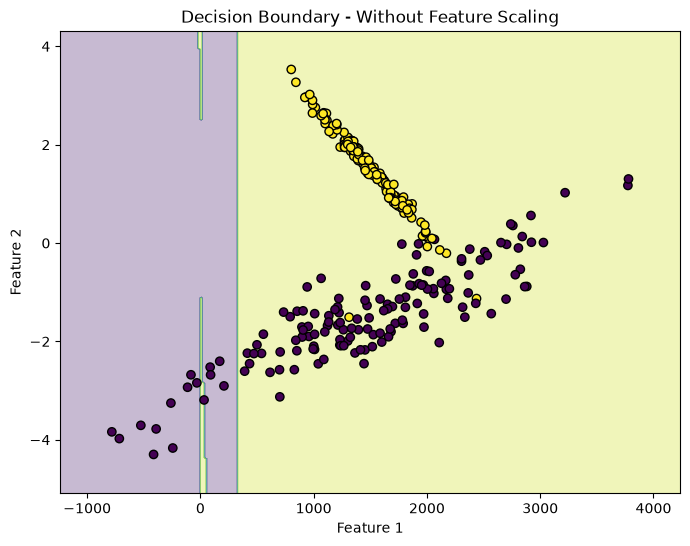

In [32]:
plot_boundary_unscaled(
    model_unscaled,
    X_test,
    y_test
)

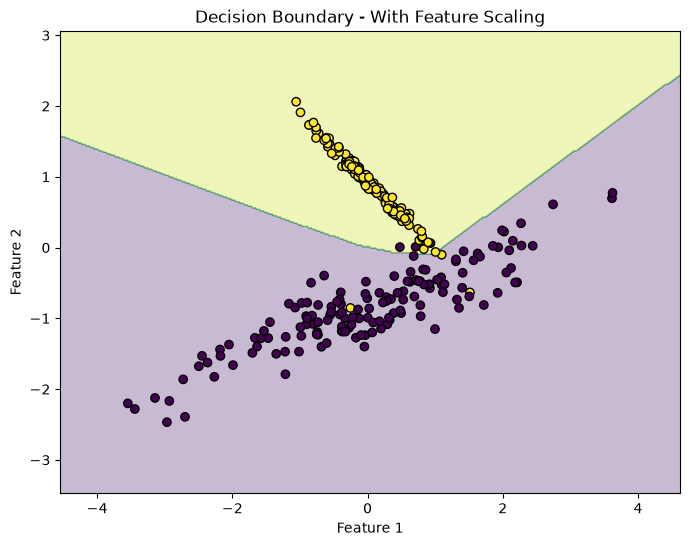

In [33]:
plot_decision_boundary(
    model_scaled,
    X_test_scaled,
    y_test,
    "Decision Boundary - With Feature Scaling"
)

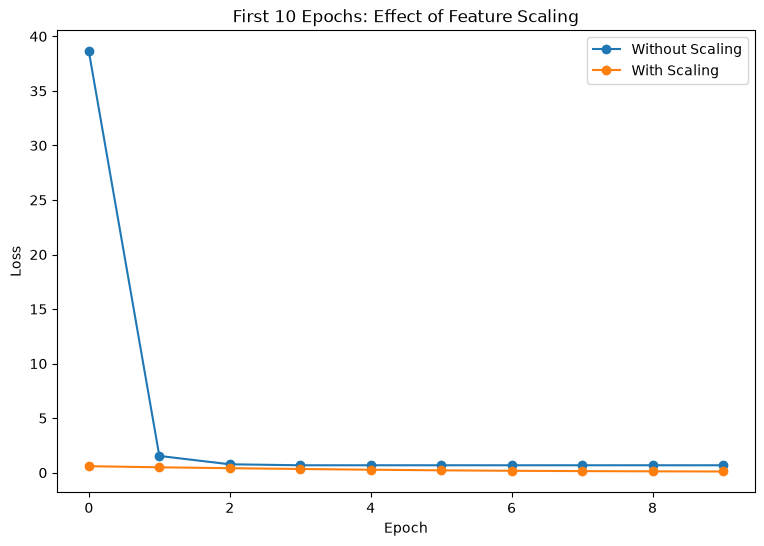

In [34]:
plt.figure(figsize=(9, 6))

plt.plot(
    history_unscaled.history["loss"][:10],
    marker="o",
    label="Without Scaling"
)

plt.plot(
    history_scaled.history["loss"][:10],
    marker="o",
    label="With Scaling"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "First 10 Epochs: Effect of Feature Scaling"
)

plt.legend()
plt.show()